# MPS vs TTN: Heston Path Generation Comparison

Loads saved checkpoints from `paper_reproduction.ipynb` (`mps_heston.jld2`) and
`ttn_training.ipynb` (`ttn_heston.jld2`), regenerates reference Heston data with
the same hyperparameters recorded in each bundle, and compares:

- Training / validation NLL
- Marginal bucket distributions
- Mean ± std bands and path spaghetti plots
- **Lag-1 bucket autocorrelation** (Markovian persistence diagnostic)

If the two bundles used different `(M, m, D_max)` settings, each model is compared
to its own reference data; a warning is printed when configs differ.

In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, "../.."))
Pkg.resolve()
Pkg.instantiate()

using MPSFast
using MPSFast.Encoders
using JLD2
using Random, Statistics, Printf
using Plots

  Activating project at `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl`
     Project No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Project.toml`
    Manifest No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Manifest.toml`


## 1. Load saved bundles

In [2]:
bundle_dir = @__DIR__
mps_path   = joinpath(bundle_dir, "mps_heston.jld2")
ttn_path   = joinpath(bundle_dir, "ttn_heston.jld2")

isfile(mps_path) || error("Missing $mps_path — run paper_reproduction.ipynb §6 first.")
isfile(ttn_path) || error("Missing $ttn_path — run ttn_training.ipynb §8 first.")

mps, mps_nll_hist, mps_epoch, mps_meta = load_mps_bundle(mps_path)
@load ttn_path ttn ttn_nll_hist ttn_val_nll ttn_meta

function encoder_from_meta(meta)
    enc = BasisEncoder(meta["m"])
    enc.Smin = meta["Smin"]
    enc.Smax = meta["Smax"]
    return enc
end

enc_mps = encoder_from_meta(mps_meta)
enc_ttn = encoder_from_meta(ttn_meta)

println("MPS meta: ", mps_meta)
println("TTN meta: ", ttn_meta)

configs_match = (
    mps_meta["M"] == ttn_meta["M"] &&
    mps_meta["m"] == ttn_meta["m"] &&
    mps_meta["Smin"] == ttn_meta["Smin"] &&
    mps_meta["Smax"] == ttn_meta["Smax"]
)
if !configs_match
    @warn "MPS and TTN bundles use different grid / horizon settings — side-by-side plots use separate reference data per model."
end

MPS meta: Dict{String, Any}("M" => 10, "m" => 5, "N_train" => 10000, "n_epochs" => 100, "encoder" => "BasisEncoder", "Smax" => 114.20428775564797, "D_max" => 150, "Smin" => 82.72887652018126)
TTN meta: Dict{String, Any}("M" => 8, "m" => 4, "N_train" => 10000, "n_epochs" => 200, "encoder" => "BasisEncoder", "Smax" => 113.61407719821013, "D_max" => 64, "Smin" => 85.22643503830835)


┌ Warning: MPS and TTN bundles use different grid / horizon settings — side-by-side plots use separate reference data per model.
└ @ Main /Users/bi006881/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/notebooks/experiments/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sZmlsZQ==.jl:31


## 2. Reference Heston data (same seed & size as training)

In [3]:
function simulate_heston(
    N::Int, M::Int;
    S0 = 100.0, V0 = 0.04, κ = 2.0, θ = 0.04,
    ξ = 0.3, ρ = -0.7, r = 0.0, dt = 1/252,
    rng = Random.default_rng(),
)
    S = Matrix{Float64}(undef, N, M)
    V = Matrix{Float64}(undef, N, M)
    for i in 1:N
        s = S0;  v = V0
        for t in 1:M
            z1 = randn(rng);  z2 = randn(rng)
            w1 = z1
            w2 = ρ * z1 + sqrt(1 - ρ^2) * z2
            v  = max(v + κ * (θ - v) * dt + ξ * sqrt(max(v, 0.0) * dt) * w2, 0.0)
            s  = s * exp((r - 0.5 * v) * dt + sqrt(max(v, 0.0) * dt) * w1)
            S[i, t] = s
            V[i, t] = v
        end
    end
    return S, V
end

rng_ref = MersenneTwister(2024)

N_mps = mps_meta["N_train"]
M_mps = mps_meta["M"]
paths_mps, _ = simulate_heston(N_mps, M_mps; rng = rng_ref)
xi_mps_ref   = encode_paths(enc_mps, paths_mps)
d_mps        = site_dim(enc_mps)

rng_ref2 = MersenneTwister(2024)
N_ttn = ttn_meta["N_train"]
M_ttn = ttn_meta["M"]
paths_ttn, _ = simulate_heston(N_ttn, M_ttn; rng = rng_ref2)
xi_ttn_ref   = encode_paths(enc_ttn, paths_ttn)
d_ttn        = site_dim(enc_ttn)

println("Reference MPS: ", size(paths_mps), "  d=", d_mps)
println("Reference TTN: ", size(paths_ttn), "  d=", d_ttn)

Reference MPS: (10000, 10)  d=32
Reference TTN: (10000, 8)  d=16


## 3. NLL summary

Model     Train NLL    Val NLL   NLL/site    Max-ent
MPS          13.614          —      1.361     34.657
TTN          10.439     11.325      1.305     22.181


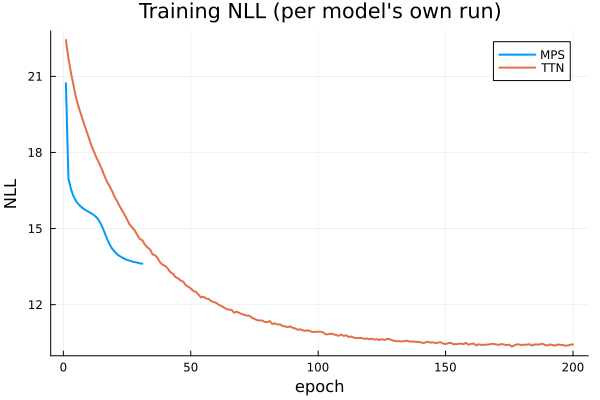

In [4]:
maxent(m, d) = m * log(d)

@printf "%-8s %10s %10s %10s %10s\n" "Model" "Train NLL" "Val NLL" "NLL/site" "Max-ent"
@printf "%-8s %10.3f %10s %10.3f %10.3f\n" "MPS" mps_nll_hist[end] "—" mps_nll_hist[end]/M_mps maxent(M_mps, d_mps)
ttn_val = isempty(ttn_val_nll) ? NaN : ttn_val_nll[end]
@printf "%-8s %10.3f %10.3f %10.3f %10.3f\n" "TTN" ttn_nll_hist[end] ttn_val ttn_nll_hist[end]/M_ttn maxent(M_ttn, d_ttn)

p_nll = plot(title = "Training NLL (per model's own run)")
plot!(p_nll, mps_nll_hist, label = "MPS", lw = 2)
plot!(p_nll, ttn_nll_hist, label = "TTN", lw = 2)
xlabel!(p_nll, "epoch"); ylabel!(p_nll, "NLL")
display(p_nll)

## 4. Sample from both models

In [5]:
N_samp = 2_000
seed   = 0

t_mps = @elapsed begin
    mps_paths, mps_xi = sample_paths(enc_mps, mps, N_samp; seed = seed)
end
t_ttn = @elapsed begin
    ttn_paths, ttn_xi = sample_ttn(enc_ttn, ttn, N_samp; seed = seed)
end

println("Sampling ", N_samp, " paths:  MPS ", round(t_mps, digits=3), " s  |  TTN ", round(t_ttn, digits=3), " s")

Sampling 2000 paths:  MPS 6.958 s  |  TTN 11.772 s


## 5. Lag-1 bucket autocorrelation

Measures step-to-step persistence in **encoded** paths. Heston data should show
positive lag-1 correlation; a generative model that learns marginals but not
dynamics often shows correlation near zero.

MPS horizon M=10:
  Data lag-1 corr : 0.9042
  MPS sample      : 0.7843
TTN horizon M=8:
  Data lag-1 corr : 0.8605
  TTN sample      : 0.1534


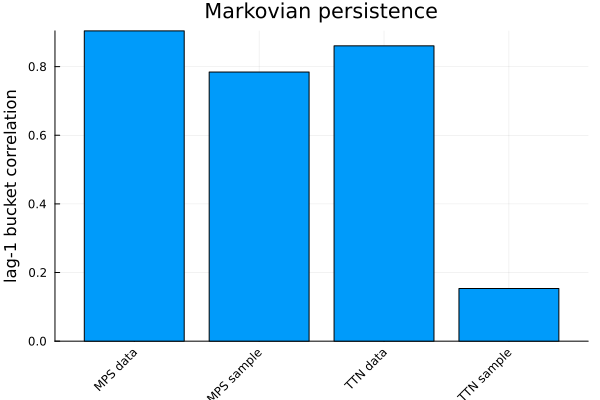

In [6]:
lag1_corr(xi) = cor(xi[:, 1:end-1][:], xi[:, 2:end][:])

lag_mps_data = lag1_corr(xi_mps_ref)
lag_mps_samp = lag1_corr(mps_xi)
lag_ttn_data = lag1_corr(xi_ttn_ref)
lag_ttn_samp = lag1_corr(ttn_xi)

@printf "MPS horizon M=%d:\n" M_mps
@printf "  Data lag-1 corr : %.4f\n" lag_mps_data
@printf "  MPS sample      : %.4f\n" lag_mps_samp
@printf "TTN horizon M=%d:\n" M_ttn
@printf "  Data lag-1 corr : %.4f\n" lag_ttn_data
@printf "  TTN sample      : %.4f\n" lag_ttn_samp

labels = ["MPS data", "MPS sample", "TTN data", "TTN sample"]
vals   = [lag_mps_data, lag_mps_samp, lag_ttn_data, lag_ttn_samp]
bar(labels, vals, ylabel = "lag-1 bucket correlation", title = "Markovian persistence", legend = false, xrotation = 45)

## 6. Path spaghetti (subset)

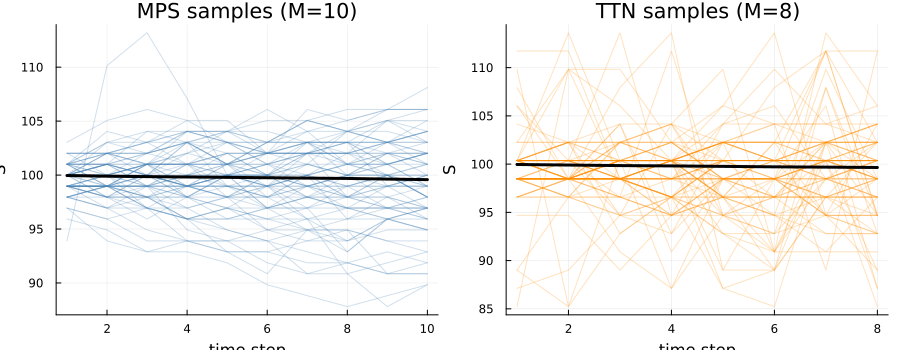

In [7]:
n_show = 80

p_mps = plot(title = "MPS samples (M=$M_mps)", legend = false)
for i in 1:n_show
    plot!(p_mps, mps_paths[i, :], alpha = 0.25, color = :steelblue)
end
plot!(p_mps, mean(paths_mps, dims=1)[:], lw = 3, color = :black, label = "data mean")
xlabel!(p_mps, "time step"); ylabel!(p_mps, "S")

p_ttn = plot(title = "TTN samples (M=$M_ttn)", legend = false)
for i in 1:n_show
    plot!(p_ttn, ttn_paths[i, :], alpha = 0.25, color = :darkorange)
end
plot!(p_ttn, mean(paths_ttn, dims=1)[:], lw = 3, color = :black, label = "data mean")
xlabel!(p_ttn, "time step"); ylabel!(p_ttn, "S")

plot(p_mps, p_ttn, layout = (1, 2), size = (900, 350))

## 7. Marginal bucket frequencies

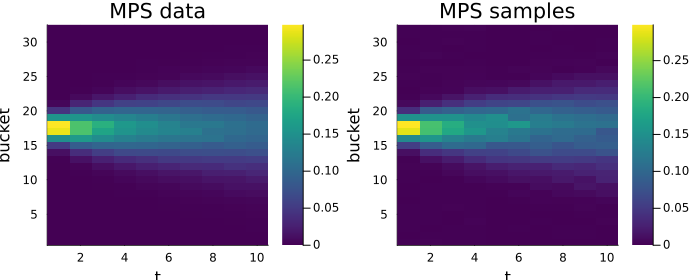

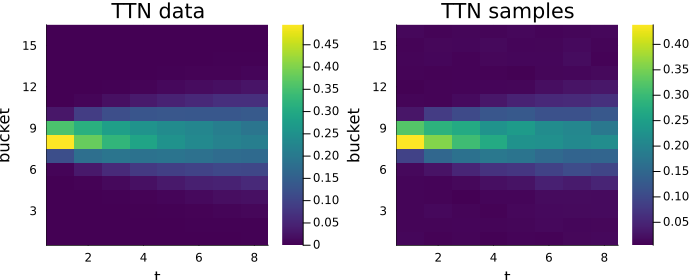

In [8]:
function marginal_heatmap(xi_ref, xi_samp, d, title_prefix)
    N, Mloc = size(xi_ref)
    data_m = [count(==(σ), xi_ref[:, t]) / N for σ in 1:d, t in 1:Mloc]
    samp_m = [count(==(σ), xi_samp[:, t]) / size(xi_samp, 1) for σ in 1:d, t in 1:Mloc]
    p1 = heatmap(data_m, title = title_prefix * " data", xlabel = "t", ylabel = "bucket", color = :viridis)
    p2 = heatmap(samp_m, title = title_prefix * " samples", xlabel = "t", ylabel = "bucket", color = :viridis)
    plot(p1, p2, layout = (1, 2), size = (700, 280))
end

display(marginal_heatmap(xi_mps_ref, mps_xi, d_mps, "MPS"))
display(marginal_heatmap(xi_ttn_ref, ttn_xi, d_ttn, "TTN"))

## 8. Mean ± std bands

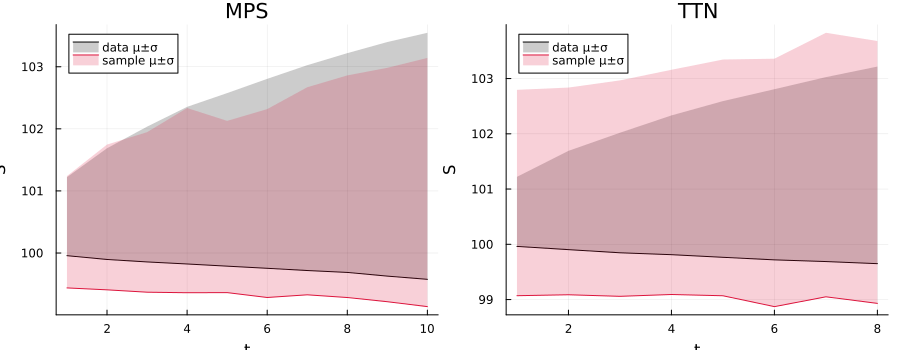

In [9]:
function mean_std_band(paths_ref, paths_samp, title)
    μ_d = mean(paths_ref, dims = 1)[:]
    σ_d = std(paths_ref, dims = 1)[:]
    μ_s = mean(paths_samp, dims = 1)[:]
    σ_s = std(paths_samp, dims = 1)[:]
    t = 1:size(paths_ref, 2)
    p = plot(title = title, legend = :topleft)
    plot!(p, t, μ_d, fillrange = μ_d .+ σ_d, fillalpha = 0.2, label = "data μ±σ", color = :black)
    plot!(p, t, μ_s, fillrange = μ_s .+ σ_s, fillalpha = 0.2, label = "sample μ±σ", color = :crimson)
    xlabel!(p, "t"); ylabel!(p, "S")
    return p
end

plot(
    mean_std_band(paths_mps, mps_paths, "MPS"),
    mean_std_band(paths_ttn, ttn_paths, "TTN"),
    layout = (1, 2), size = (900, 350)
)

## 9. Discussion

- **NLL / marginals**: both architectures can fit bucket histograms when bond dimension is adequate.
- **Lag-1 correlation**: the chain MPS typically preserves more step-to-step structure than the tree TTN on the same Heston task, because the MPS factorisation follows the time ordering.
- **Sampling cost**: TTN tree sampling is often slower per path when bond dimensions are comparable (see §4 timings).
- Re-run training notebooks with matched `(M, m, D_max)` if you want apples-to-apples overlays on a single reference dataset.